DATA ACQUISITION & PREPROCESSING

In [161]:
# Import Libraries
import tf2onnx
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [162]:
# Load MNIST Dataset
mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Each image:28 × 28 grayscale / pixels

In [163]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


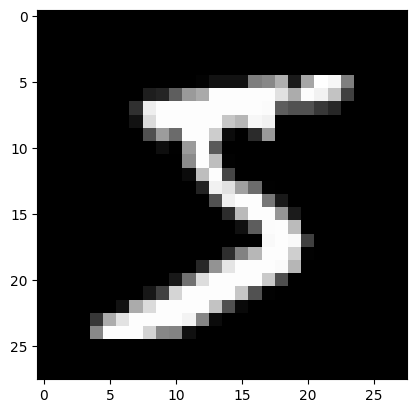

In [164]:
plt.imshow(X_train[0], cmap='gray')
plt.show()

In [165]:
print(y_train[0])

5


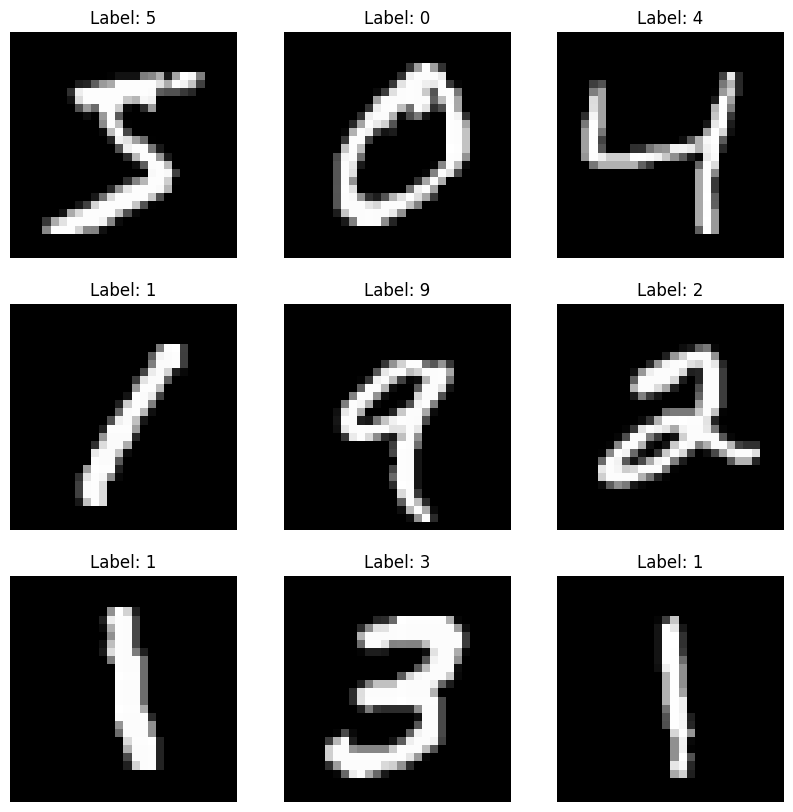

In [166]:
# Display Multiple Digits
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title(f"Label: {y_train[i]}")

    plt.axis('off')

plt.show()

In [167]:
# NORMALIZATION
X_train = X_train / 255.0

X_test = X_test / 255.0

In [168]:
print(X_train[0].max())
print(X_train[0].min())

1.0
0.0


In [169]:
# FLATTENING => 28 x 28 = 784
X_train = X_train.reshape(60000, 784)

X_test = X_test.reshape(10000, 784)

print(X_train.shape)

print(X_test.shape)


(60000, 784)
(10000, 784)


## ANN ARCHITECTURE & TRAINING

In [170]:
# Import Keras Components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# INPUT LAYER + FIRST HIDDEN LAYER
model.add(Dense(
    128,
    activation='relu',
    input_shape=(784,)
))

model.add(Dropout(0.2))

# SECOND HIDDEN LAYER
model.add(Dense(
    64,
    activation='relu'
))

model.add(Dropout(0.2))

# OUTPUT LAYER
model.add(Dense(
    10,
    activation='softmax'
))

d:\ML\Resume_Analyzer_using_ANN\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [171]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [172]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.8943 - loss: 0.3514 - val_accuracy: 0.9700 - val_loss: 0.1136
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9496 - loss: 0.1695 - val_accuracy: 0.9710 - val_loss: 0.1047
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9614 - loss: 0.1274 - val_accuracy: 0.9748 - val_loss: 0.0807
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9664 - loss: 0.1084 - val_accuracy: 0.9787 - val_loss: 0.0745
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9709 - loss: 0.0966 - val_accuracy: 0.9785 - val_loss: 0.0718
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9739 - loss: 0.0836 - val_accuracy: 0.9810 - val_loss: 0.0728
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9752 - loss: 0.0793 - val_accuracy: 0.9832 - val_loss: 0.0755
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9769 - loss: 0.0734 -

EVALUATION & MODEL EXPORT

In [173]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9782 - loss: 0.0720
Test Loss: 0.07198207080364227
Test Accuracy: 0.9782000184059143


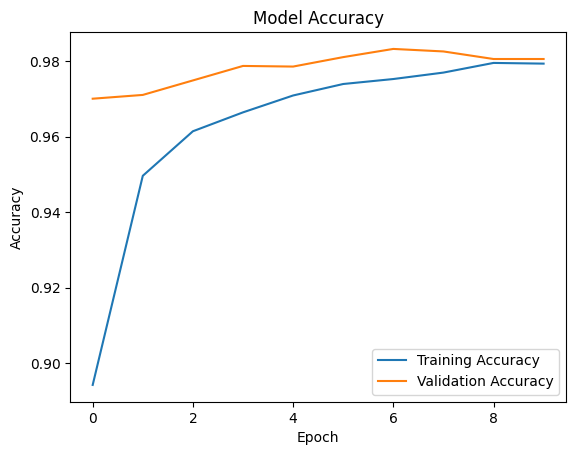

In [174]:
# Plot Accuracy
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

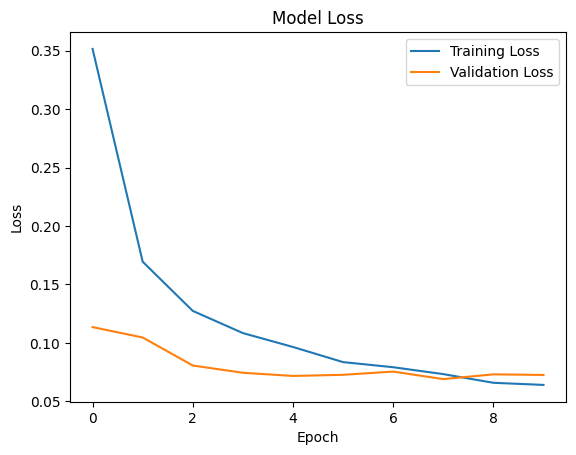

In [175]:
# Plot Loss
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [176]:
import tensorflow as tf

# Load the model
model = tf.keras.models.load_model(r"D:\ML\Resume_Analyzer_using_ANN\models\mnist_ann_model.keras")

# Use export() to create the SavedModel directory
model.export(r"D:\ML\Resume_Analyzer_using_ANN\models\mnist_saved_model_dir")
print("SavedModel folder successfully created!")

INFO:tensorflow:Assets written to: D:\ML\Resume_Analyzer_using_ANN\models\mnist_saved_model_dir\assets


INFO:tensorflow:Assets written to: D:\ML\Resume_Analyzer_using_ANN\models\mnist_saved_model_dir\assets


Saved artifact at 'D:\ML\Resume_Analyzer_using_ANN\models\mnist_saved_model_dir'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='input_layer_9')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  3091282157328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3091282159248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3091282159632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3091282159056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3090971601104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3090971591504: TensorSpec(shape=(), dtype=tf.resource, name=None)
SavedModel folder successfully created!
